In [4]:
import sys
import numpy as np
from numpy.linalg import norm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

plt.style.use({
    'font.family':        'serif',
    'font.serif':         ['DejaVu Sans'],
    'mathtext.fontset':   'stixsans',
    'figure.figsize':     (6,4),
    'text.usetex':        False,
    'figure.dpi':         120,
    'savefig.dpi':        250,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.1,
    'axes.prop_cycle':    plt.cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', 
                                               '#d62728', '#9467bd', '#8c564b', 
                                               '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
})



In [5]:
k_lims=np.array([0.06725096, 2.69003852])
ell_lims = np.array([10**2, 4000])   

df=pd.read_csv('pge_comparison.csv')
df2=pd.read_csv('pge_unncut.csv')

In [136]:
4000*2/2.6

3076.9230769230767

/tmp/ipykernel_29853/2243390535.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax0.set_yticklabels([1,2,3])


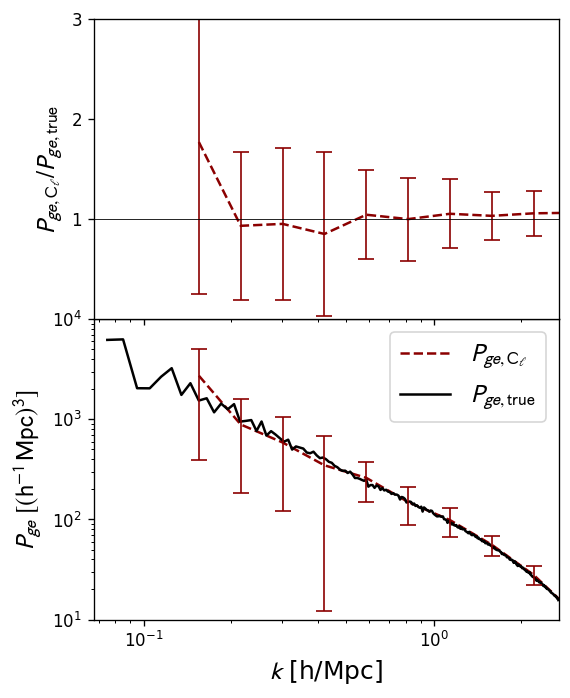

In [6]:

fontsize=15
fig = plt.figure(figsize=(5,6.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[.5, 1],hspace=0.35)
sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2], hspace=0)

ax = plt.subplot(sub_gs[1])  # upper plot that shows DM sfunc
ax0 = plt.subplot(sub_gs[0], sharex=ax)  # second subplot shows histogram of FRBs

colors = sns.color_palette('flare')[2:]
color='darkred'
xlabel='$k$ [h/Mpc]'
ylabel=r'$P_{ge}~[(\mathrm{h}^{-1}\,\mathrm{Mpc})^3]$'

ax.set_xlabel(xlabel,fontsize=fontsize)
ax.set_ylabel(ylabel,fontsize=fontsize)
            

ax.plot(df['k'],df['Pk'],color=color,lw=1.5,ls='--',label=r'$P_{ge,\rm{C_{\ell}}}$')
ax.plot(df2['k_ge'], df2['P_ge'], color='k',lw=1.5,label=r'$P_{ge,\rm{true}}$',ls='-')
ax.errorbar(df['k'],df['Pk'],yerr=df['Pk_err'],color=color,capsize=5,lw=1,ls='None')

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=fontsize)


ax.set_ylim(10,10**4)

ax.set_xlim(min(k_lims),max(k_lims))

ax0.errorbar(df['k'],df['Pk']/df['Pge_theory'],yerr=df['Pk_err']/df['Pge_theory'],color=color,capsize=5,lw=1,ls='None')
ax0.plot(df['k'],df['Pk']/df['Pge_theory'],color=color,lw=1.5,ls='--')

maxy=2
ax0.set_ylim(0,maxy)
ax0.axhline(1,color='k',lw=.5)
ax0.set_yticklabels([1,2,3])
ax0.set_yticks([1,2,3])
ax0.set_ylabel(r'$P_{ge,\rm{C_{\ell}}}/P_{ge,\rm{true}}$',fontsize=fontsize)
ax0.tick_params(labelbottom=False)

plt.savefig('pge_comparison.pdf')





# plot2

In [134]:
import pandas

df=pd.read_csv('non_gaussianities_vs_gaussian.csv')
ells=df['ell']
mean_midslice_ClDg=df['mean_midslice_ClDg']
mean_DeltaC=df['mean_DeltaC']
err=np.array(df['mean_midslice_ClDg_err'])

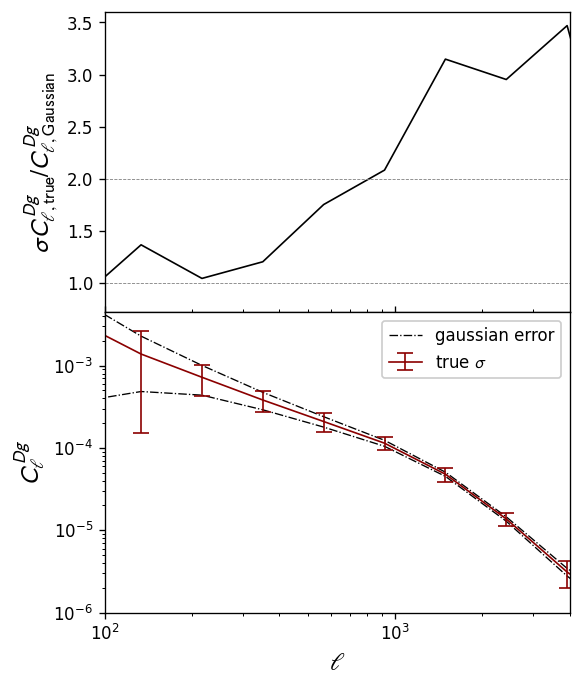

In [135]:
frb_mean_z=0.4

fontsize=15
fig = plt.figure(figsize=(5,6.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1],hspace=0.35)
sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2], hspace=0)
ax_ratios = plt.subplot(sub_gs[0])  # upper plot that shows DM sfunc
ax = plt.subplot(sub_gs[1], sharex=ax2)  # second subplot shows histogram of FRBs

ax.plot(ells, mean_midslice_ClDg-mean_DeltaC, color='k', ls='dashdot', lw=0.8, label='gaussian error')
ax.plot(ells, mean_midslice_ClDg+mean_DeltaC, color='k', ls='dashdot', lw=0.8)

ax.errorbar(ells,mean_midslice_ClDg, yerr=err,color='darkred',label=r'true $\sigma$',capsize=5,lw=1)


ax.legend()
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$\Delta C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_ylim(1e-6,6e-3)


err2=mean_DeltaC

last=1
ax_ratios.plot(ells, err/(err2), color='k', ls='-', lw=1.0)#,label='true variance/gaussian error')

ax_ratios.set_xscale('log')
ax_ratios.set_xlabel(r'$\ell$',fontsize=fontsize)
ax_ratios.set_ylabel(r'$\sigma C_{\ell,\rm{true}}^{Dg}/C_{\ell,\rm{Gaussian}}^{Dg}$',fontsize=fontsize)

ax_ratios.set_xlim(ell_lims[0],ell_lims[1])#82,10**(3.1))
ax_ratios.axhline(1.0,ls='--',color='gray',lw=.5)
ax_ratios.axhline(2.0,ls='--',color='gray',lw=.5)

ax.set_xlim(ell_lims[0],ell_lims[1])#10**(2.1),10**(3.1))
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])#10**(2.1),10**(3.1))

ax.set_ylim(1e-6,0.004455221960390097)
ax.set_yscale('log')

ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax.set_xlabel(r'$\ell$',fontsize=fontsize)
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_xscale('log')
ax.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)



plt.savefig('non_gaussianities_vs_gaussian.pdf')



# plot 3. SFR vs uniform FRB 

In [7]:
df=pd.read_csv('proj_FRBs.csv')

fid_ClDgs=df['fid_ClDgs']
fid_ClDgs_err=df['fid_ClDgs_err']
pixels=df['pixels']
ells=df['ell']


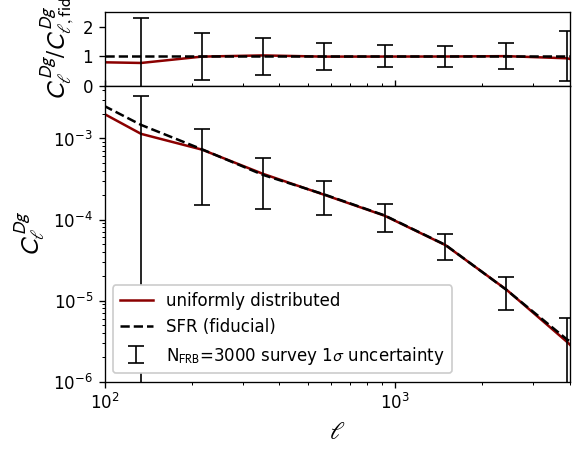

In [12]:
fontsize=15
fig = plt.figure(figsize=(5,4))
gs = gridspec.GridSpec(2, 1, height_ratios=[.5, 2],hspace=0)
ax_ratios = plt.subplot(gs[0,0])  # upper plot that shows DM sfunc
ax2 = plt.subplot(gs[1,0])#, sharex=ax)  # second subplot shows histogram of FRBs

ax_ratios.plot(ells,pixels/fid_ClDgs,color='darkred',lw=1.5)
ax_ratios.set_ylabel(r'$ C_{\ell}^{Dg}/C_{\ell,\rm{fid}}^{Dg}$',fontsize=fontsize)


ax_ratios.set_ylim(0.,2.5)
ax_ratios.set_yticks([0.0,1.0,2.0])
ax_ratios.axhline(1,ls='--',color='black')

ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")

ax2.plot(ells,pixels, color='darkred',label='uniformly distributed',lw=1.5)

ax2.plot(ells, fid_ClDgs, color='k', ls='--', lw=1.5,label='SFR (fiducial)')
ax2.errorbar(ells,fid_ClDgs, yerr=fid_ClDgs_err,color='k',capsize=5,lw=1,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")

ax2.set_ylim(1e-6,0.004455221960390097)
ax2.set_yscale('log')

ax2.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax2.set_xlabel(r'$\ell$',fontsize=fontsize)
ax2.tick_params(axis='x', which='both', top=True)
ax2.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax2.set_xscale('log')
ax2.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)

plt.savefig('proj_FRBs.pdf')



# host magnitude

In [173]:
df=pd.read_csv('host_mag_hist.csv')
m_g_mids=np.array(df['m_g_mids'][:-1])
Hmask=np.array(df['Hmask'][:-1])
H=np.array(df['H'][:-1])
m_g_bins=df['m_g_bins']

df=pd.read_csv('host_mag.csv')

fid_ClDgs=df['fid_ClDgs']
fid_ClDgs_err=df['fid_ClDgs_err']
hostmag_res=df['hostmag_res']
hostmag_res_err=df['hostmag_res_err']
ells=df['ell']


/tmp/ipykernel_29853/4009582632.py:45: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax_ratios = plt.subplot(sub_gs[0], sharex=ax)  # second subplot shows histogram of FRBs
/tmp/ipykernel_29853/4009582632.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


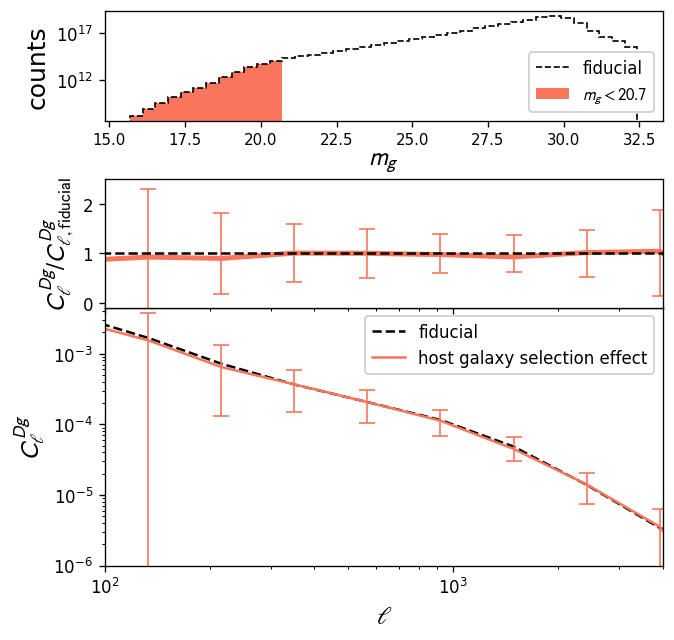

In [178]:
c=(0.973381, 0.46152, 0.361965)


gs = gridspec.GridSpec(3, 1, height_ratios=[1,1,2],hspace=.4)
fig = plt.figure(figsize=(6,6))

ax_hist = fig.add_subplot(gs[0])


sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1:3], hspace=0,height_ratios=[1,2])
ax_ratios = fig.add_subplot(sub_gs[0])
ax = fig.add_subplot(sub_gs[1])


#####################
# DM host histogram
#####################

# galaxy selection histogram
ax_hist.stairs(H / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, ls='--', label='fiducial', color='k')
ax_hist.stairs(Hmask / (0.4*10**(-0.4*m_g_mids)), -m_g_bins, fill=True, alpha=1,  label=f'$m_g < 20.7$', color=c, zorder=0)
ax_hist.set_ylabel('counts',fontsize=15)
ax_hist.set_xlabel(r'$m_g$', labelpad=2,fontsize=15)
ax_hist.set_yscale('log')
ax_hist.tick_params(axis='x', labelsize=9)
ax_hist.legend(fontsize=10, loc='lower right',framealpha=1)#, bbox_to_anchor=(0.07, .01))

#####################
# cross-correlation
#####################
#fid_ClDgs_err=plot_ref_ClDg(ax, fid_ClDgs_, label='fiducial')
ax.plot(ells, fid_ClDgs, color='k', ls='--', lw=1.5,label='fiducial')
#ax.errorbar(ells,fid_ClDgs, yerr=fid_ClDgs_err,color='k',capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.errorbar(ells,fid_ClDgs, yerr=hostmag_res_err,color=c,capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")

ax.plot(ells, hostmag_res, ls='-', lw=1.5,label='host galaxy selection effect',color=c) 
ax.set_xlabel(r'${\ell}$',fontsize=15)
ax.set_ylabel(r'$C^{Dg}_{\ell}$',fontsize=15)



#####################
# ratios
#####################
ax_ratios = plt.subplot(sub_gs[0], sharex=ax)  # second subplot shows histogram of FRBs
#ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")
ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=hostmag_res_err/np.abs(fid_ClDgs),color=c,capsize=5,lw=1,ls="None")

ax_ratios.set_ylabel(r'${C^{Dg}_{\ell}}/{C^{Dg}_{\ell,\rm{fiducial}}}$',fontsize=15)
ax_ratios.plot(ells, hostmag_res/fid_ClDgs, ls='-',label=f'$m_g < 20.7$',color=c,lw=3)
ax_ratios.plot(ells,[1]*len(ells),ls='--',color='k')
ax_ratios.set_xticklabels([]) 
ax_ratios.set_ylim(0.5,1.5)


ax.set_ylim(1e-6,6e-3)
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')
ax_ratios.tick_params(labelbottom=False)
ax.tick_params(axis='x', which='both', top=True)
ax_ratios.set_xscale('log')
ax_ratios.set_ylim(-0.1,2.5)



ax.set_ylim(1e-6,0.004455221960390097)
ax.set_yscale('log')
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax.set_xlabel(r'$\ell$',fontsize=fontsize)
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_xscale('log')
ax.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)

plt.tight_layout()
plt.savefig('host_mag.pdf')

## DM Host

In [142]:
df=pd.read_csv('hostDM.csv')
hostDM=df['hostDM']
hostDM_err=df['hostDM_err']

df=pd.read_csv('host_mag_dist.csv')
DMs_=df['DMs_']
PDMs_=df['PDMs_']

df=pd.read_csv('host_mag_hist.csv')
H_fid_host=np.array(df['H_fid_host'][:-1])
DM_mids_=np.array(df['DM_mids_'][:-1])
H_fid=np.array(df['H_fid'][:-1])
bins=df['bins']


/tmp/ipykernel_29853/3436466321.py:60: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax_err_ratios = plt.subplot(sub_gs[0], sharex=ax)  # second subplot shows histogram of FRBs
/tmp/ipykernel_29853/3436466321.py:80: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax_ratios = plt.subplot(sub_gs[1], sharex=ax)  # second subplot shows histogram of FRBs
/tmp/ipykernel_29853/3436466321.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


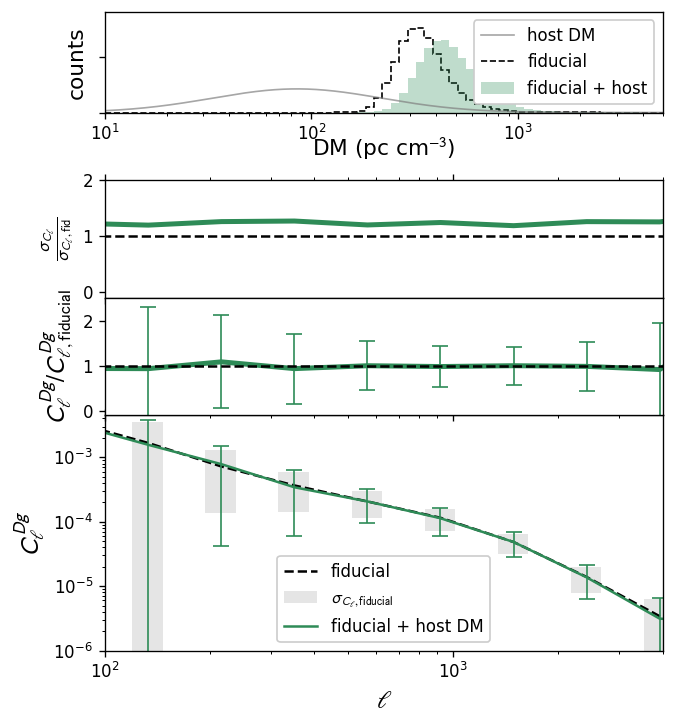

In [171]:
n_frbs = 3000
gs = gridspec.GridSpec(4, 1, height_ratios=[.5,1,1,2],hspace=.3)
fig = plt.figure(figsize=(6,12))

ax_hist = fig.add_subplot(gs[0])

sub_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[1:3], hspace=0,height_ratios=[1,1,2])
ax_err_ratios = fig.add_subplot(sub_gs[0])
ax_ratios = fig.add_subplot(sub_gs[1])
ax = fig.add_subplot(sub_gs[2])

c = 'seagreen'

#####################
# DM host histogram
#####################
_ = ax_hist.plot(DMs_, PDMs_ * DMs_, color='gray', label='host DM', lw=1, alpha=0.7)
_ = ax_hist.stairs(H_fid * DM_mids_, bins, color='k', label='fiducial', ls='--')
_ = ax_hist.stairs(H_fid_host * DM_mids_, bins, color=c, label='fiducial + host',fill=True, alpha=0.3)

ax_hist.set_xlabel('DM (pc cm$^{-3}$)', labelpad=-5,fontsize=13)
ax_hist.set_ylabel(r'counts',fontsize=13)
ax_hist.set_xscale('log')
ax_hist.set_xlim((10, 5e3))
# ax_hist.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_hist.set_yticks([0, 1])
ax_hist.set_yticklabels([])
ax_hist.set_ylim(0, 1.8)
ax_hist.legend(fontsize=10,loc='upper right',framealpha=1)


#####################
# cross-correlation
#####################
#fid_ClDgs_err=plot_ref_ClDg(ax, fid_ClDgs_, label='fiducial')
ax.plot(ells, fid_ClDgs, color='k', ls='--', lw=1.5,label='fiducial')

#ax.errorbar(ells,fid_ClDgs, yerr=fid_ClDgs_err,color='k',capsize=5,lw=2,ls="None",alpha=.5)#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
i=0
for x, y, err in zip(ells, fid_ClDgs, fid_ClDgs_err):
    if i==0:    
        rect = plt.Rectangle((x - 0.1 * x, y - err), 0.2 * x, 2 * err,label=r'$\sigma_{C_\ell,\rm{fiducial}}$',
                             linewidth=0, edgecolor=None, facecolor='gray', alpha=0.2)
    else:
        rect = plt.Rectangle((x - 0.1 * x, y - err), 0.2 * x, 2 * err,
                             linewidth=0, edgecolor=None, facecolor='gray', alpha=0.2)
    i+=1
    
    ax.add_patch(rect)
ax.errorbar(ells,hostDM, yerr=hostDM_err,color=c,capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.plot(ells, hostDM, ls='-', lw=1.5,label='fiducial + host DM',color=c) 
ax.set_xlabel(r'${\ell}$',fontsize=15)
ax.set_ylabel(r'$C^{Dg}_{\ell}$',fontsize=15)



#####################
# errratios
#####################
ax_err_ratios = plt.subplot(sub_gs[0], sharex=ax)  # second subplot shows histogram of FRBs
#ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")
#ax_err_ratios.errorbar(ells,hostDM/fid_ClDgs, yerr=hostDM_err/np.abs(fid_ClDgs),color=c,capsize=5,lw=1,ls="None")

ax_err_ratios.set_ylabel(r'$\frac{\sigma_{C_{\ell}}}{\sigma_{C_{\ell},\rm{fid}}}$',fontsize=15)
ax_err_ratios.plot(ells, hostDM_err/fid_ClDgs_err, ls='-',color=c,lw=3)
ax_err_ratios.plot(ells,[1]*len(ells),ls='--',color='k')
ax_err_ratios.set_xticklabels([]) 

ax_err_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_err_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_err_ratios.set_xscale('log')
ax_err_ratios.tick_params(labelbottom=False)
ax_err_ratios.tick_params(axis='x', which='both', top=True)
ax_err_ratios.set_xscale('log')
ax_err_ratios.set_ylim(-0.1,2)

#####################
# ratios
#####################
ax_ratios = plt.subplot(sub_gs[1], sharex=ax)  # second subplot shows histogram of FRBs
#ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")
ax_ratios.errorbar(ells,hostDM/fid_ClDgs, yerr=hostDM_err/np.abs(fid_ClDgs),color=c,capsize=5,lw=1,ls="None")

ax_ratios.set_ylabel(r'${C^{Dg}_{\ell}}/{C^{Dg}_{\ell,\rm{fiducial}}}$',fontsize=15)
ax_ratios.plot(ells, hostDM/fid_ClDgs, ls='-',label=f'$m_g < 20.7$',color=c,lw=3)
ax_ratios.plot(ells,[1]*len(ells),ls='--',color='k')
ax_ratios.set_xticklabels([]) 

ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')
ax_ratios.tick_params(labelbottom=False)
ax.tick_params(axis='x', which='both', top=True)
ax_ratios.set_xscale('log')
ax_ratios.set_ylim(-0.1,2.5)


ax.set_ylim(1e-6,0.004455221960390097)
ax.set_yscale('log')
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax.set_xlabel(r'$\ell$',fontsize=fontsize)
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_xscale('log')
ax.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)


plt.tight_layout()
plt.savefig('hostDM_onelegend.pdf')

/tmp/ipykernel_29853/4049017330.py:54: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax_ratios = plt.subplot(sub_gs[0], sharex=ax)  # second subplot shows histogram of FRBs
/tmp/ipykernel_29853/4049017330.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


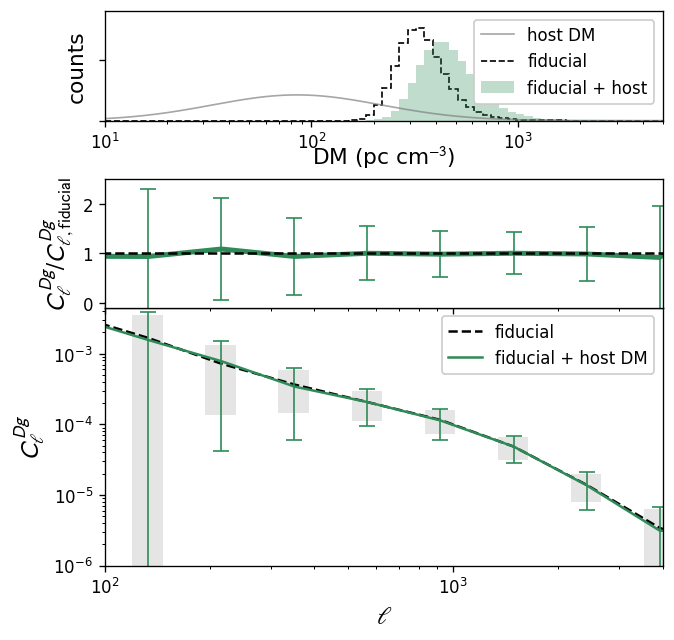

In [149]:
n_frbs = 3000
gs = gridspec.GridSpec(3, 1, height_ratios=[1,1,2],hspace=.4)
fig = plt.figure(figsize=(6,6))

ax_hist = fig.add_subplot(gs[0])


sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1:3], hspace=0,height_ratios=[1,2])
ax_ratios = fig.add_subplot(sub_gs[0])
ax = fig.add_subplot(sub_gs[1])

c = 'seagreen'

#####################
# DM host histogram
#####################
_ = ax_hist.plot(DMs_, PDMs_ * DMs_, color='gray', label='host DM', lw=1, alpha=0.7)
_ = ax_hist.stairs(H_fid * DM_mids_, bins, color='k', label='fiducial', ls='--')
_ = ax_hist.stairs(H_fid_host * DM_mids_, bins, color=c, label='fiducial + host',fill=True, alpha=0.3)

ax_hist.set_xlabel('DM (pc cm$^{-3}$)', labelpad=-5,fontsize=13)
ax_hist.set_ylabel(r'counts',fontsize=13)
ax_hist.set_xscale('log')
ax_hist.set_xlim((10, 5e3))
# ax_hist.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_hist.set_yticks([0, 1])
ax_hist.set_yticklabels([])
ax_hist.set_ylim(0, 1.8)
ax_hist.legend(fontsize=10,loc='upper right',framealpha=1)


#####################
# cross-correlation
#####################
#fid_ClDgs_err=plot_ref_ClDg(ax, fid_ClDgs_, label='fiducial')
ax.plot(ells, fid_ClDgs, color='k', ls='--', lw=1.5,label='fiducial')

#ax.errorbar(ells,fid_ClDgs, yerr=fid_ClDgs_err,color='k',capsize=5,lw=2,ls="None",alpha=.5)#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
for x, y, err in zip(ells, fid_ClDgs, fid_ClDgs_err):
    rect = plt.Rectangle((x - 0.1 * x, y - err), 0.2 * x, 2 * err,
                         linewidth=0, edgecolor=None, facecolor='gray', alpha=0.2)
    ax.add_patch(rect)
ax.errorbar(ells,hostDM, yerr=hostDM_err,color=c,capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.plot(ells, hostDM, ls='-', lw=1.5,label='fiducial + host DM',color=c) 
ax.set_xlabel(r'${\ell}$',fontsize=15)
ax.set_ylabel(r'$C^{Dg}_{\ell}$',fontsize=15)




#####################
# ratios
#####################
ax_ratios = plt.subplot(sub_gs[0], sharex=ax)  # second subplot shows histogram of FRBs
#ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")
ax_ratios.errorbar(ells,hostDM/fid_ClDgs, yerr=hostDM_err/np.abs(fid_ClDgs),color=c,capsize=5,lw=1,ls="None")

ax_ratios.set_ylabel(r'${C^{Dg}_{\ell}}/{C^{Dg}_{\ell,\rm{fiducial}}}$',fontsize=15)
ax_ratios.plot(ells, hostDM/fid_ClDgs, ls='-',label=f'$m_g < 20.7$',color=c,lw=3)
ax_ratios.plot(ells,[1]*len(ells),ls='--',color='k')
ax_ratios.set_xticklabels([]) 

ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')
ax_ratios.tick_params(labelbottom=False)
ax.tick_params(axis='x', which='both', top=True)
ax_ratios.set_xscale('log')
ax_ratios.set_ylim(-0.1,2.5)


ax.set_ylim(1e-6,0.004455221960390097)
ax.set_yscale('log')
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax.set_xlabel(r'$\ell$',fontsize=fontsize)
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_xscale('log')
ax.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)


plt.tight_layout()
plt.savefig('hostDM_onelegend.pdf')

### DM dependent

In [179]:
import pandas

df=pd.read_csv('DM_sfunc_realistic.csv')
DM_sfunc=df['DM_sfunc']
DM_sfunc_err=df['DM_sfunc_err']

df=pd.read_csv('DM_sfunc_realistic_smooth_sfunc_a_2.csv')
smooth_sfunc=df['smooth_sfunc']
DMs_=df['DMs_']
smooth_sfunc_old=smooth_sfunc

df=pd.read_csv('DM_sfunc_realistic_DM_hist.csv')
bin_midpoints=np.array(df['bin_midpoints'])[:-1]
H_smooth=np.array(df['H_smooth'])[:-1]
bins=np.array(df['bins'])
H=np.array(df['H'])[:-1]


/tmp/ipykernel_29853/2456346115.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


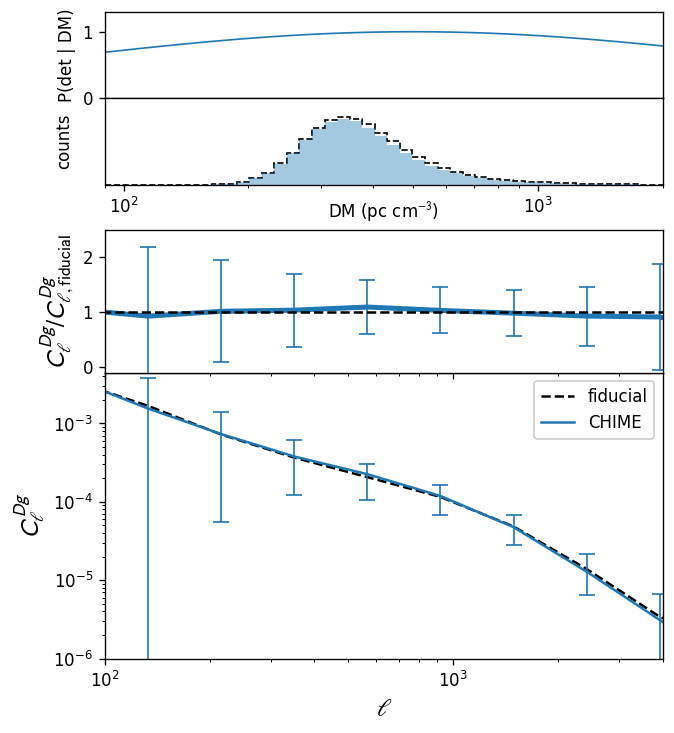

In [181]:
c_smooth = '#1f77b4'
c_step = '#d62728'
c=c_smooth

a=2

fig = plt.figure(figsize=(6,7))
gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 1, 5],hspace=0.35)
sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2], hspace=0)
ax_s = plt.subplot(sub_gs[0])  # upper plot that shows DM sfunc
ax_hist = plt.subplot(sub_gs[1], sharex=ax_s)  # second subplot shows histogram of FRBs
sub_gs2 = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1,2],subplot_spec=gs[2:4], hspace=0)


DMs_ = np.logspace(1, 4, 10000)
ax_s.plot(DMs_, smooth_sfunc, color=c_smooth, lw=1, label='CHIME')

bins = np.logspace(1, 4, 100)
bin_midpoints = (bins[:-1] + bins[1:]) / 2
ax_hist.stairs(H*bin_midpoints, bins, color='black', ls='--')
ax_hist.stairs(H_smooth*bin_midpoints, bins, color=c_smooth, fill=True, alpha=0.4)

ax_s.set_ylabel('P(det | DM)')

ax_s.set_ylim(0,1)
ax_s.set_xlim(90, 2e3)
ax_s.set_xscale('log')
ax_s.set_ylim(top=1.3)
ax_s.set_yticks([0, 1])

#ax_hist.set_ylabel('DM ' + r'$\times$' + ' counts', labelpad=19)
ax_hist.set_ylabel('counts', labelpad=19)
ax_hist.set_xlabel('DM (pc ' + r'cm$^{-3}$)', labelpad=-10)
ax_hist.set_ylim(0, 1.9e7)
ax_hist.set_yticks([])
#ax_s.set_xticklabels([])
#ax_hist.set_xticks([100,1000])
ax = plt.subplot(sub_gs2[-1])  # Third subplot (independent x-axis)


#####################
# cross-correlation
#####################
#fid_ClDgs_err=plot_ref_ClDg(ax, fid_ClDgs_, label='fiducial')
ax.plot(ells, fid_ClDgs, color='k', ls='--', lw=1.5,label='fiducial')
#ax.errorbar(ells,fid_ClDgs, yerr=fid_ClDgs_err,color='k',capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.errorbar(ells,fid_ClDgs, yerr=DM_sfunc_err,color=c,capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.plot(ells, DM_sfunc, ls='-', lw=1.5,label='CHIME',color=c) 
ax.set_xlabel(r'${\ell}$',fontsize=15)
ax.set_ylabel(r'$C^{Dg}_{\ell}$',fontsize=15)




#####################
# ratios
#####################
ax_ratios = plt.subplot(sub_gs2[0], sharex=ax)  # second subplot shows histogram of FRBs
#ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")
ax_ratios.errorbar(ells,DM_sfunc/fid_ClDgs, yerr=DM_sfunc_err/np.abs(fid_ClDgs),color=c,capsize=5,lw=1,ls="None")

ax_ratios.set_ylabel(r'${C^{Dg}_{\ell}}/{C^{Dg}_{\ell,\rm{fiducial}}}$',fontsize=15)
ax_ratios.plot(ells, DM_sfunc/fid_ClDgs, ls='-',color=c,lw=3)
ax_ratios.plot(ells,[1]*len(ells),ls='--',color='k')
ax_ratios.set_xticklabels([]) 

ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')
ax_ratios.tick_params(labelbottom=False)
ax.tick_params(axis='x', which='both', top=True)
ax_ratios.set_xscale('log')
ax_ratios.set_ylim(-0.1,2.5)


ax.set_ylim(1e-6,0.004455221960390097)
ax.set_yscale('log')
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax.set_xlabel(r'$\ell$',fontsize=fontsize)
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_xscale('log')
ax.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)


plt.tight_layout()

plt.savefig('DM_sfunc_realistic.pdf')


In [59]:
bins.shape

(100,)

In [182]:
import pandas
df=pd.read_csv('DM_sfunc.csv')
DM_cutoff=df['DM_cutoff']
DM_cutoff_err=df['DM_cutoff_err']
DM_sfunc=df['DM_sfunc']
DM_sfunc_err=df['DM_sfunc_err']

df=pd.read_csv('DM_func_a_5.csv')
cutoff_func=df['cutoff_func']
smooth_sfunc=df['smooth_sfunc']
DMs_=df['DMs_']

df=pd.read_csv('DM_sfunc_realistic_DM_hist.csv')
bin_midpoints=np.array(df['bin_midpoints'])[:-1]
H_smooth=np.array(df['H_smooth'])[:-1]
bins=np.array(df['bins'])
H=np.array(df['H'])[:-1]


/tmp/ipykernel_29853/3091093526.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


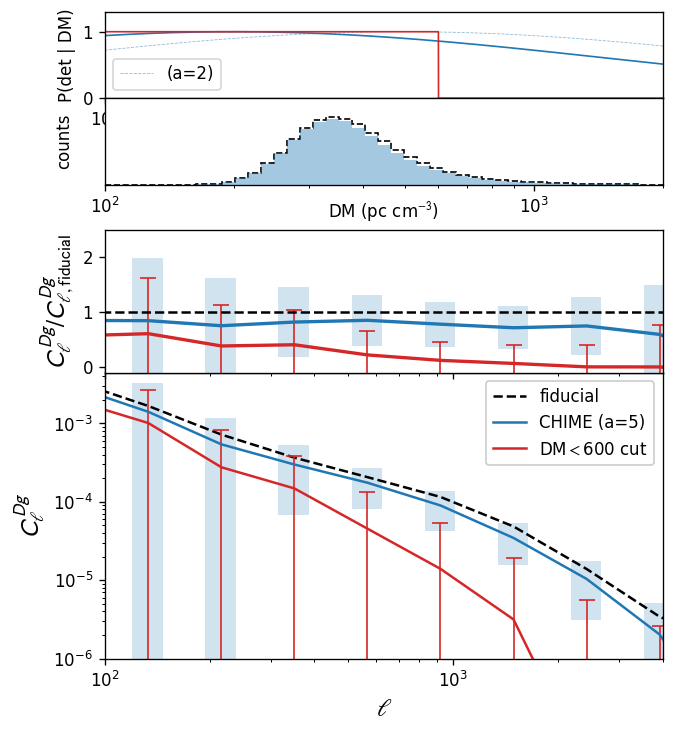

In [189]:

fig = plt.figure(figsize=(6,7))
gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 1, 5],hspace=0.35)
sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2], hspace=0)

ax_s = plt.subplot(sub_gs[0])  # upper plot that shows DM sfunc
ax_hist = plt.subplot(sub_gs[1], sharex=ax_s)  # second subplot shows histogram of FRBs


sub_gs2 = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1,2],subplot_spec=gs[2:4], hspace=0)

ax = plt.subplot(sub_gs2[-1])  # Third subplot (independent x-axis)

DMs_ = np.logspace(1, 4, 10000)
ax_s.plot(DMs_, smooth_sfunc, color=c_smooth, lw=1)#,label='CHIME (a=5)')#, label='smooth selection')
ax_s.plot(DMs_, smooth_sfunc_old, color=c_smooth, alpha=.5,lw=.5,ls='--', label='(a=2)')
ax_s.plot(DMs_, cutoff_func, color=c_step, lw=1)#,label='DM$<$600 cut')

bins = np.logspace(1, 4, 100)
bin_midpoints = (bins[:-1] + bins[1:]) / 2
ax_hist.stairs(H*bin_midpoints, bins, color='k', ls='--')
ax_hist.stairs(H_smooth*bin_midpoints, bins, color=c_smooth, fill=True, alpha=0.4)
ax_s.legend(loc='lower left')
ax_s.set_ylabel('P(det | DM)')
ax_s.set_ylim(0,1)
ax_s.set_xlim(100, 2e3)
ax_s.set_xscale('log')
ax_s.set_ylim(top=1.3)
ax_s.set_yticks([0, 1])

#ax_hist.set_ylabel('DM ' + r'$\times$' + ' counts', labelpad=19)
ax_hist.set_ylabel('counts', labelpad=19)
ax_hist.set_xlabel('DM (pc ' + r'cm$^{-3}$)', labelpad=-10)
ax_hist.set_ylim(0, 1.9e7)
ax_hist.set_yticks([])
#ax_s.set_xticklabels([])
ax_hist.set_xticks([100,1000])
#ax_hist.set_yticklabels([])
#ax_hist.set_xticks([100,1000])

#####################
# cross-correlation
#####################
#fid_ClDgs_err=plot_ref_ClDg(ax, fid_ClDgs_, label='fiducial')
ax.plot(ells, fid_ClDgs, color='k', ls='--', lw=1.5,label='fiducial')
#ax.errorbar(ells,fid_ClDgs, yerr=fid_ClDgs_err,color='k',capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
#ax.errorbar(ells,DM_sfunc, yerr=DM_sfunc_err,color=c,capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
i=0
for x, y, err in zip(ells, DM_sfunc, DM_sfunc_err):
    if False:#i==0:    
        rect = plt.Rectangle((x - 0.1 * x, y - err), 0.2 * x, 2 * err,label=r'$\sigma_{C_\ell,\rm{a=5}}$',
                             linewidth=0, edgecolor=None, facecolor=c, alpha=0.2)
    else:
        rect = plt.Rectangle((x - 0.1 * x, y - err), 0.2 * x, 2 * err,
                             linewidth=0, edgecolor=None, facecolor=c, alpha=0.2)
    i+=1
    
    ax.add_patch(rect)
    
ax.errorbar(ells,DM_cutoff, yerr=DM_cutoff_err,color=c_step,capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.plot(ells, DM_sfunc, ls='-', lw=1.5,label='CHIME (a=5)',color=c) 
ax.plot(ells, DM_cutoff, ls='-', lw=1.5,label='DM$<$600 cut',color=c_step) 
ax.set_xlabel(r'${\ell}$',fontsize=15)
ax.set_ylabel(r'$C^{Dg}_{\ell}$',fontsize=15)




#####################
# ratios
#####################
ax_ratios = plt.subplot(sub_gs2[0], sharex=ax)  # second subplot shows histogram of FRBs
#ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")
#ax_ratios.errorbar(ells,DM_sfunc/fid_ClDgs, yerr=DM_sfunc_err/np.abs(fid_ClDgs),color=c,capsize=5,lw=1,ls="None")

for x, y, err in zip(ells, DM_sfunc/fid_ClDgs, DM_sfunc_err/fid_ClDgs):
    if False:#i==0:    
        rect = plt.Rectangle((x - 0.1 * x, y - err), 0.2 * x, 2 * err,label=r'$\sigma_{C_\ell,\rm{a=5}}$',
                             linewidth=0, edgecolor=None, facecolor=c, alpha=0.2)
    else:
        rect = plt.Rectangle((x - 0.1 * x, y - err), 0.2 * x, 2 * err,
                             linewidth=0, edgecolor=None, facecolor=c, alpha=0.2)
    i+=1
    
    ax_ratios.add_patch(rect)
    

ax_ratios.errorbar(ells,DM_cutoff/fid_ClDgs, yerr=DM_cutoff_err/np.abs(fid_ClDgs),color=c_step,capsize=5,lw=1,ls="None")

ax_ratios.set_ylabel(r'${C^{Dg}_{\ell}}/{C^{Dg}_{\ell,\rm{fiducial}}}$',fontsize=15)
ax_ratios.plot(ells, DM_sfunc/fid_ClDgs, ls='-',color=c,lw=2)
ax_ratios.plot(ells, DM_cutoff/fid_ClDgs, ls='-',color=c_step,lw=2)
ax_ratios.plot(ells,[1]*len(ells),ls='--',color='k')
ax_ratios.set_xticklabels([]) 

ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')
ax_ratios.tick_params(labelbottom=False)
ax.tick_params(axis='x', which='both', top=True)
ax_ratios.set_xscale('log')
ax_ratios.set_ylim(-0.1,2.5)


ax.set_ylim(1e-6,0.004455221960390097)
ax.set_yscale('log')
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax.set_xlabel(r'$\ell$',fontsize=fontsize)
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_xscale('log')
ax.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)


plt.tight_layout()
plt.savefig('DM_sfunc.pdf')

## scattering

In [190]:
import pandas
df=pd.read_csv('scattering.csv')
scatter_ClDgs=df['scatter_ClDgs']
scatter_ClDgs_err=df['scatter_ClDgs_err']
df=pd.read_csv('scattering_probs.csv')
scatterbins=df['scatterbins']
Hscatter=np.array(df['Hscatter'])[:-1]


df=pd.read_csv('scattering_probs.csv')
scatterbins=df['scatterbins']
Hscatter=np.array(df['Hscatter'])[:-1]

df=pd.read_csv('scattering_DM_hist.csv')
H_fid=np.array(df['H_fid'])[:-1]
bin_midpoints=np.array(df['bin_midpoints'])[:-1]
bins=df['bins']
H_scatter=np.array(df['H_scatter'])[:-1]


/tmp/ipykernel_29853/252205488.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


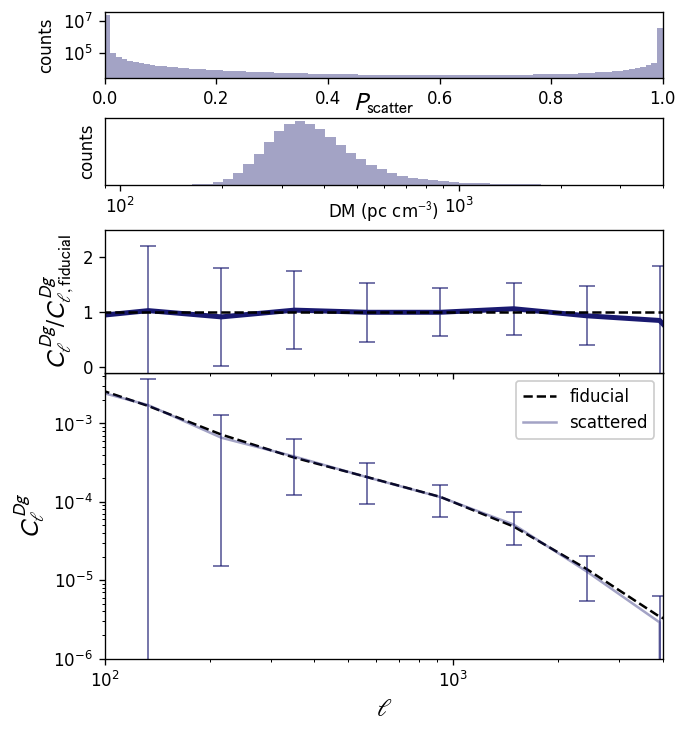

In [196]:
c = 'midnightblue'

fig = plt.figure(figsize=(6,7))
gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 1, 5],hspace=0.35)
sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2], hspace=0.6)
sub_gs2 = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1,2],subplot_spec=gs[2:4], hspace=0)

ax_hist = plt.subplot(sub_gs[0])  # upper plot that shows DM sfunc
ax_hist_DM = plt.subplot(sub_gs[1])  # second subplot shows histogram of FRBs
ax_hist.stairs(Hscatter, scatterbins, fill=True, color=c, alpha=0.4)
ax_hist.set_yscale('log')
ax_hist.set_xlabel(r'$P_{\rm{scatter}}$', labelpad=-10,fontsize=15)
ax_hist.set_ylabel('counts', labelpad=5)
ax_hist.set_xlim(0,1)

#####################
#DM_hist
#####################
ax_hist_DM.stairs(H_scatter*bin_midpoints, bins, color=c, fill=True, alpha=0.4, label='fiducial + scattering')
ax_hist_DM.set_ylabel('counts', labelpad=5)
ax_hist_DM.set_xlabel('DM (pc ' + r'cm$^{-3}$)', labelpad=-10)
ax_hist_DM.set_xscale('log')
ax_hist_DM.set_xlim((90, 4000))
#ax_hist_DM.set_yscale('log')
#ax_hist.set_yticks([])
ax_hist_DM.set_yticks([])

ax = plt.subplot(sub_gs2[1])  # upper plot that shows DM sfunc

#####################
# cross-correlation
#####################
#fid_ClDgs_err=plot_ref_ClDg(ax, fid_ClDgs_, label='fiducial')
ax.plot(ells, fid_ClDgs, color='k', ls='--', lw=1.5,label='fiducial')
#ax.errorbar(ells,fid_ClDgs, yerr=fid_ClDgs_err,color='k',capsize=5,lw=1,ls="None")#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.errorbar(ells,scatter_ClDgs, yerr=scatter_ClDgs_err,color=c,capsize=5,lw=1,ls="None", alpha=0.7)#,label=r'N$_{\rm{FRB}}$=3000 survey 1$\sigma$ uncertainty',ls="None")
ax.plot(ells, scatter_ClDgs, ls='-', lw=1.5,label='scattered',color=c, alpha=0.4)
ax.set_xlabel(r'${\ell}$',fontsize=15)
ax.set_ylabel(r'$C^{Dg}_{\ell}$',fontsize=15)




#####################
# ratios
#####################
ax_ratios = plt.subplot(sub_gs2[0], sharex=ax)  # second subplot shows histogram of FRBs
#ax_ratios.errorbar(ells,fid_ClDgs/fid_ClDgs, yerr=fid_ClDgs_err/np.abs(fid_ClDgs),color='k',capsize=5,lw=1,ls="None")
ax_ratios.errorbar(ells,scatter_ClDgs/fid_ClDgs, yerr=scatter_ClDgs_err/np.abs(fid_ClDgs),color=c,capsize=5,lw=1,ls="None", alpha=0.7)

ax_ratios.set_ylabel(r'${C^{Dg}_{\ell}}/{C^{Dg}_{\ell,\rm{fiducial}}}$',fontsize=15)
ax_ratios.plot(ells, scatter_ClDgs/fid_ClDgs, ls='-',color=c,lw=3)
ax_ratios.plot(ells,[1]*len(ells),ls='--',color='k')
ax_ratios.set_xticklabels([]) 

ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')
ax_ratios.tick_params(labelbottom=False)
ax.tick_params(axis='x', which='both', top=True)
ax_ratios.set_xscale('log')
ax_ratios.set_ylim(-0.1,2.5)


ax.set_ylim(1e-6,0.004455221960390097)
ax.set_yscale('log')
ax.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xlim(ell_lims[0],ell_lims[1])
ax_ratios.set_xscale('log')

ax.set_xlabel(r'$\ell$',fontsize=fontsize)
ax.tick_params(axis='x', which='both', top=True)
ax.set_ylabel(r'$ C_{\ell}^{Dg}$',fontsize=fontsize)
ax.set_xscale('log')
ax.legend(framealpha=1)
ax_ratios.tick_params(labelbottom=False)


plt.tight_layout()

plt.savefig( 'scattering.pdf')